# RNA Polymerase II Elongation Rate Analysis

## Overview

This project investigates the relationship between RNA Polymerase II (Pol II) density and transcriptional elongation rate using gene-expression and elongation-rate data from MCF7 cells.

The analysis tests whether genes with greater Pol II density in the gene body also exhibit different transcriptional elongation rates. I compare linear and logarithmic regression models to quantify this relationship and examine how the empirical relationship affects a model of RNA production.

The analysis includes:

- integrating Pol II elongation-rate and gene-expression datasets;
- visualising the relationship between Pol II density and elongation rate;
- calculating the correlation between the variables;
- fitting a linear regression model;
- deriving an RNA production equation from the empirical relationship;
- fitting a logarithmic regression model;
- comparing the linear and logarithmic models; and
- evaluating which model provides a better description of the observed data.

## Tools

- R
- ggplot2
- Linear regression
- Logarithmic regression
- Correlation analysis
- Statistical model comparison
- Gene-expression analysis
- Quantitative biology

## Biological Context

RNA Polymerase II (Pol II) transcribes DNA into RNA. During transcription, Pol II moves along the gene while producing the RNA transcript.

The analysis considers the relationship between:

- **[P]** — Pol II density within the gene body
- **r** — transcriptional elongation rate

The rate of RNA production can be represented as:

$$
\frac{d[R]}{dt} = r[P]
$$

where [R] represents RNA production.

The aim is to determine whether the elongation rate can be empirically related to Pol II density and incorporate this relationship into the RNA production model.

## Data Processing

I first loaded measurements of transcriptional elongation rates and gene-expression estimates for MCF7 cells.

The datasets were filtered to retain measurements corresponding to the 10–40 minute experimental interval and then merged using the gene identifier.

Only the variables required for the analysis were retained.


In [14]:
# Read in the elongation rates.
rates <- read.table(
    "data/GSE41324_MCF7.10-40m.regressionRate.tsv",
    header = TRUE
)
head(rates)

# Read gene-expression data
expression <- read.table(
  "data/MCF7.AC16.allExpr.Rflat",
  header = TRUE
)

# Keep expression estimates corresponding to the 10–40 minute interval
expression <- expression[c(expression$V9 == "10-40m"),]
head(expression)

# Merge the datasets
merged_data <- merge(
  rates,
  expression,
  by.x = "uniqueID",
  by.y = "V4"
)

# Retain variables required for analysis
merged_data <- merged_data[, c(
  "uniqueID",
  "chrom",
  "chromStart",
  "chromEnd",
  "strand",
  "rate",
  "EXPR"
)]

head(merged_data)

,chrom,chromStart,chromEnd,uniqueID,rate,strand,medianDist10,medianDist25,medianDist40
,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<int>,<int>,<int>
1,chr3,57969166,58133022,chr3_57969166_58133022_+,1.961497,+,16100,36700,81400
2,chr14,90807419,90953886,chr14_90807419_90953886_-,2.080000,-,13700,40800,77500
3,chr14,92473011,92652016,chr14_92473011_92652016_-,3.084490,-,4400,40500,106700
4,chr1,21416326,21544621,chr1_21416326_21544621_-,2.445000,-,12700,37400,82700
5,chr17,72789086,73008273,chr17_72789086_73008273_+,1.968299,+,16500,30700,67400
6,chr3,66511910,66633535,chr3_66511910_66633535_-,1.946882,-,28600,42500,84900


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,EXPR
,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>
1,chr3,57969166,58133022,chr3_57969166_58133022_+,1.961497,+,163,5.062571,10-40m,MCF7,115497.13
2,chr14,90807419,90953886,chr14_90807419_90953886_-,2.080000,-,106,5.016248,10-40m,MCF7,103812.00
3,chr14,92473011,92652016,chr14_92473011_92652016_-,3.084490,-,245,4.924505,10-40m,MCF7,84043.62
4,chr1,21416326,21544621,chr1_21416326_21544621_-,2.445000,-,360,4.910301,10-40m,MCF7,81339.33
5,chr17,72789086,73008273,chr17_72789086_73008273_+,1.968299,+,264,4.828843,10-40m,MCF7,67428.45
6,chr3,66511910,66633535,chr3_66511910_66633535_-,1.946882,-,323,4.820897,10-40m,MCF7,66205.90


,uniqueID,chrom,chromStart,chromEnd,strand,rate,EXPR
,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>
1,chr1_15123211_15267238_+,chr1,15123211,15267238,+,1.900000,37361.07
2,chr1_160306204_160606437_+,chr1,160306204,160606437,+,2.993741,32459.44
3,chr1_17719200_17902750_+,chr1,17719200,17902750,+,2.292000,59092.50
4,chr1_198273750_198413950_+,chr1,198273750,198413950,+,1.330000,13529.38
5,chr1_21416326_21544621_-,chr1,21416326,21544621,-,2.445000,81339.33
6,chr1_65071493_65204775_-,chr1,65071493,65204775,-,2.440727,33373.17


## 1. Relationship Between Pol II Density and Elongation Rate

I first examined whether elongation rate was associated with Pol II density using a scatter plot and linear regression.

`geom_smooth()` using formula = 'y ~ x'


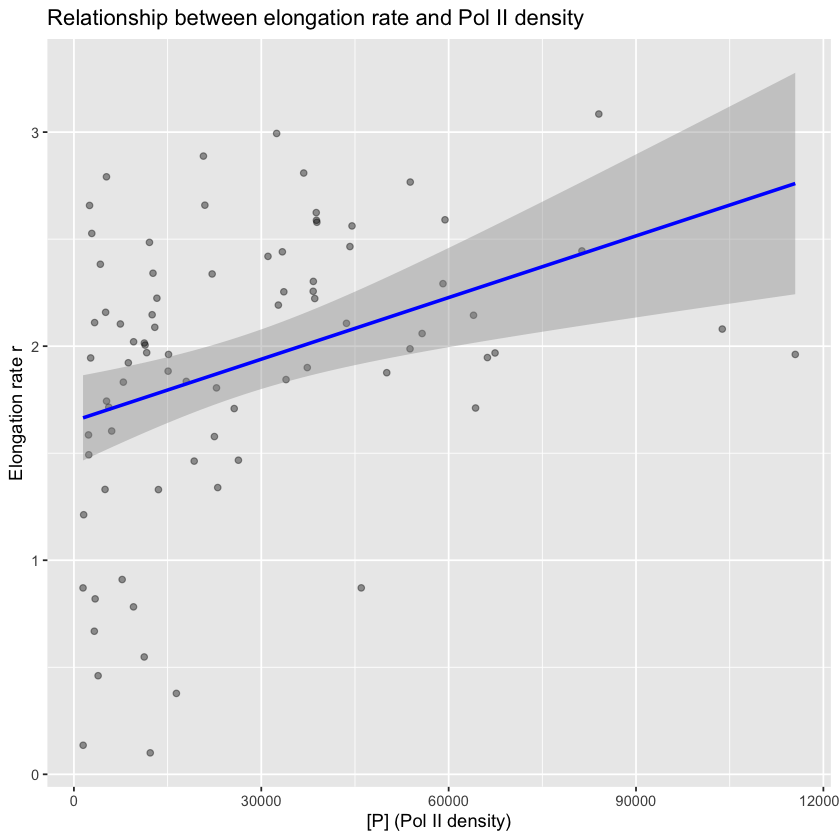

In [20]:
library(ggplot2)
# Visualise the relationship between Pol II density and elongation rate
ggplot(merged_data, aes(x = EXPR, y = rate)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", color = "blue") +
  labs(
    x = "[P] (Pol II density)", 
    y = "Elongation rate r",
       title = "Relationship between elongation rate and Pol II density")


### Interpretation

The scatter plot shows a positive relationship between Pol II density and elongation rate. However, the points show substantial variation around the fitted regression line, indicating that Pol II density alone does not explain all of the variation in elongation rate.

## 2. Correlation Analysis

I calculated the correlation coefficient between Pol II density and elongation rate.

In [16]:
cor.test(merged_data$EXPR, merged_data$rate)


	Pearson's product-moment correlation

data:  merged_data$EXPR and merged_data$rate
t = 3.3953, df = 79, p-value = 0.001075
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1502045 0.5336210
sample estimates:
      cor 
0.3568502 


### Interpretation
The correlation coefficient is 0.357, which suggests a positive correlation but it is not strong.
This suggests that genes with higher Pol II density tend to have higher elongation rates, but the relationship is not strong enough to explain the majority of variation between genes.

## 3. Linear Regression Model

I next fitted a linear model of the form:

r = c1 ∗[P]+c2 
This relates the elongation rate, r, to the amount of Pol II transcribing through the gene body, [P]. 

In [17]:
model_linear <- lm(rate ~ EXPR, data = merged_data)
summary(model_linear)


Call:
lm(formula = rate ~ EXPR, data = merged_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.66818 -0.33982  0.08745  0.44540  1.09001 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.651e+00  1.030e-01  16.023  < 2e-16 ***
EXPR        9.600e-06  2.827e-06   3.395  0.00108 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6249 on 79 degrees of freedom
Multiple R-squared:  0.1273,	Adjusted R-squared:  0.1163 
F-statistic: 11.53 on 1 and 79 DF,  p-value: 0.001075


### Interpretation
The fitted relationship was approximately:

r=9.60×10−6[P]+1.651

The positive slope ((9.6×10⁻⁶) ) indicates that elongation rate increases with Pol II density.

The model had an R² of approximately 0.127, meaning that Pol II density explained approximately 12.7% of the variation in elongation rate in this model.
Although the relationship is statistically significant since (p = 0.00108), suggesting that variation in Pol II density explains part of the variation in elongation rate the relatively low R² indicates that additional factors contribute substantially to variation in transcriptional elongation rate.

## 4. Implications for RNA Production

The RNA production model is:

$$
\frac{d[R]}{dt} = r[P]
$$

Using the empirical linear relationship:

$$
r = 9.60 \times 10^{-6}[P] + 1.651
$$

gives:

$$
\frac{d[R]}{dt}
=
[P](9.60 \times 10^{-6}[P] + 1.651)
$$

Therefore:

$$
\frac{d[R]}{dt}
=
9.60 \times 10^{-6}[P]^2 + 1.651[P]
$$

This provides a model of RNA production in which the production rate depends directly on Pol II density, incorporating the observed relationship between Pol II density and elongation rate.

## 5. Logarithmic Model

I then tested whether a logarithmic relationship provided a better description of the data:

$$
r = c_1\log[P] + c_2
$$


In [18]:
model_log <- lm(rate ~ log(EXPR), data = merged_data)
summary(model_log)


Call:
lm(formula = rate ~ log(EXPR), data = merged_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7360 -0.3164  0.1052  0.3665  1.2244 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.55712    0.59023  -0.944    0.348    
log(EXPR)    0.25432    0.06046   4.207 6.79e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6047 on 79 degrees of freedom
Multiple R-squared:  0.183,	Adjusted R-squared:  0.1727 
F-statistic:  17.7 on 1 and 79 DF,  p-value: 6.788e-05


### Interpretation
The fitted logarithmic relationship was approximately:

$$
r = 0.25432\log[P] - 0.55712
$$

The logarithmic model produced a higher $R^2$ of approximately 0.183, compared with 0.127 for the linear model. It also produced a lower residual standard error (0.6047 compared with 0.6249).

These results suggest that the logarithmic model provides a better statistical fit to the data than the linear model, although Pol II density still explains only a relatively small proportion of the variation in elongation rate.

Under the logarithmic model:

$$
\frac{d[R]}{dt}
=
[P](0.25432\log[P] - 0.55712)
$$

or:

$$
\frac{d[R]}{dt}
=
0.25432[P]\log[P] - 0.55712[P]
$$

However, model selection should not rely on a single statistic. Residual behaviour, AIC, predictive performance, and biological plausibility should also be considered. Therefore, these results provide evidence that the logarithmic model fits these data better, but do not establish that it is universally the correct biological model.

## 6. Linear vs Logarithmic Model

I compared both regression models visually by plotting their fitted relationships over the observed data.

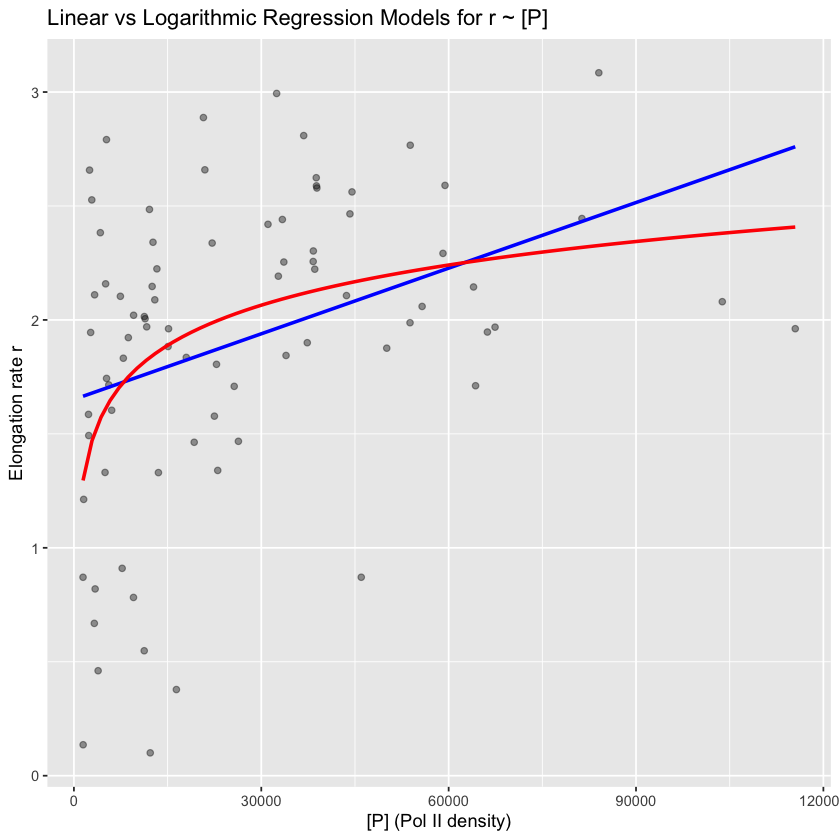

In [22]:
library(ggplot2)

ggplot(merged_data, aes(x = EXPR, y = rate)) +
  geom_point(alpha = 0.4) +

  # Linear regression line
  geom_smooth(method = "lm", formula = y ~ x,
              color = "blue", se = FALSE, size = 1) +

  # Logarithmic regression line
  geom_smooth(method = "lm", formula = y ~ log(x),
              color = "red", se = FALSE, size = 1) +

  labs(x = "[P] (Pol II density)",
       y = "Elongation rate r",
       title = "Linear vs Logarithmic Regression Models for r ~ [P]")
  


### Interpretaion

When plotting both regression lines, the log model (red curve) follows the distribution of the data more closely than the linear model (blue line). The log curve rises steeply at low Pol II density and flattens at higher density, whereas the linear fit remains too shallow and does not capture the curvature in the data. This matches the statistical results from above where the log model showed higher R² and lower residual error. Therefore, the visual plot supports the conclusion that the logarithmic model better represents the relationship between elongation rate and Pol II density.Interpretation

## Conclusion

This analysis investigated the relationship between Pol II density and transcriptional elongation rate using MCF7 gene-expression data.

The results showed a positive association between Pol II density and elongation rate, although the relatively modest correlation and R² indicate that Pol II density explains only part of the observed variation.

Comparing linear and logarithmic models suggested that the logarithmic relationship provided a better fit to the data. Incorporating this empirical relationship into the RNA production equation also demonstrated how statistical modelling can be connected to quantitative models of transcription.

Overall, the project demonstrates how biological data can be integrated with statistical modelling to investigate relationships between molecular measurements and develop quantitative descriptions of biological processes.

## Key Skills Demonstrated
- R programming
- Data manipulation and integration
- ggplot2
- Correlation analysis
- Linear regression
- Non-linear/log-transformed regression
- Statistical model comparison
- Quantitative modelling
- Gene-expression analysis
- Mathematical modelling of transcription

## Academic Context

This project was completed as part of Computational Biology coursework at Cornell University.

The repository presents my implementation, analysis and interpretation as part of my personal computational biology portfolio.

### Data Availability

The datasets used in the original practical were provided as part of the course materials and are not included in this repository. The code is provided to demonstrate the computational workflow and analysis.